## <center> Predictive Modeling for Agriculture <center>

In [465]:
# Import required modules
import pandas as pd
import numpy as np
from statsmodels.formula.api import logit
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

In [466]:
# Import the 'car_insurance.csv' dataset
df = pd.read_csv("C:/Users/uyen/Desktop/Real-World-Projects/Python/datasets/car_insurance.csv")
df.head()

,id,age,gender,driving_experience,education,income,credit_score,vehicle_ownership,vehicle_year,married,children,postal_code,annual_mileage,vehicle_type,speeding_violations,duis,past_accidents,outcome
0,569520,3,0,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,0,1,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,0,0,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,0,1,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,1,1,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


In [467]:
# Select 'object' datatype columns
col = [x for x in df.columns if df[x].dtype == 'object']
col

['driving_experience', 'education', 'income', 'vehicle_year', 'vehicle_type']

In [468]:
# Observe unique values of 'object' columns in the dataframe
# df["driving_experience"].unique()
for i in col:
    print(i.title(),":", df[i].unique())

Driving_Experience : ['0-9y' '10-19y' '20-29y' '30y+']
Education : ['high school' 'none' 'university']
Income : ['upper class' 'poverty' 'working class' 'middle class']
Vehicle_Year : ['after 2015' 'before 2015']
Vehicle_Type : ['sedan' 'sports car']


In [469]:
# Replace categories with the correct values 
driving_exp_dict = {"0-9y": 0, "10-19y": 1, "20-29y": 2, "30y+": 3}
education_dict = {"none": 0, "high school": 1, "university": 2}
income_dict = {"poverty": 0, "working class": 1, "middle class": 2, "upper class": 3}
veh_year_dict = {"before 2015": 0, "after 2015": 1}
veh_type_dict = {"sedan": 0, "sports car": 1}

In [470]:
# Map the correct values
df[col[0]] = df[col[0]].map(driving_exp_dict)
df[col[1]] = df[col[1]].map(education_dict)
df[col[2]] = df[col[2]].map(income_dict)
df[col[3]] = df[col[3]].map(veh_year_dict)
df[col[4]] = df[col[4]].map(veh_type_dict)

In [471]:
# Float columns that need to be converted to integers
df["vehicle_ownership"] = df["vehicle_ownership"].astype("int")
df["married"] = df["married"].astype("int")
df["outcome"] = df["outcome"].astype("int")

In [472]:
# Checking for missing data
df.isna().sum()

id                       0
age                      0
gender                   0
driving_experience       0
education                0
income                   0
credit_score           982
vehicle_ownership        0
vehicle_year             0
married                  0
children                 0
postal_code              0
annual_mileage         957
vehicle_type             0
speeding_violations      0
duis                     0
past_accidents           0
outcome                  0
dtype: int64

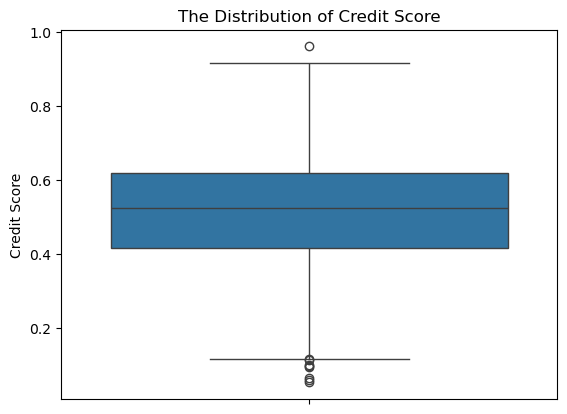

In [473]:
# Histogram to observe the distribution of 'credit_score'
sns.boxplot(df["credit_score"])
plt.title("The Distribution of Credit Score")
plt.ylabel("Credit Score")
plt.show()

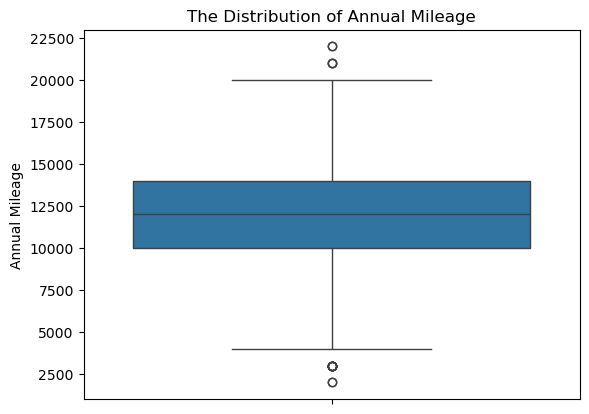

In [474]:
# Histogram to observe the distribution of 'annual_mileage'
sns.boxplot(df["annual_mileage"])
plt.title("The Distribution of Annual Mileage")
plt.ylabel("Annual Mileage")
plt.show()

In [475]:
# Impute missing values for the dataframe
imputer = SimpleImputer(missing_values=np.nan, strategy = "median")
df_imputed = imputer.fit_transform(df)
df_imputed = pd.DataFrame(df_imputed, columns = df.columns)

In [476]:
# Check the df_imputed dataframe for missing values
df_imputed.isna().sum()

id                     0
age                    0
gender                 0
driving_experience     0
education              0
income                 0
credit_score           0
vehicle_ownership      0
vehicle_year           0
married                0
children               0
postal_code            0
annual_mileage         0
vehicle_type           0
speeding_violations    0
duis                   0
past_accidents         0
outcome                0
dtype: int64

In [477]:
# Get the column names excluding the 'id' and 'outcome' columns
columns = list(df_imputed.columns)
columns = [i for i in columns if i not in ["id", "outcome"]]
columns

['age',
 'gender',
 'driving_experience',
 'education',
 'income',
 'credit_score',
 'vehicle_ownership',
 'vehicle_year',
 'married',
 'children',
 'postal_code',
 'annual_mileage',
 'vehicle_type',
 'speeding_violations',
 'duis',
 'past_accidents']

In [478]:
# Declare an empty results dictionary
results = {}

In [479]:
# Using Logistic Regression from sklearn to determine the best predictive feature
for column in columns:
    X = df_imputed[column].values
    X = X.reshape(-1,1)
    y = df["outcome"].values
    y = y.reshape(-1,1)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    logreg = LogisticRegression()
    logreg.fit(X_train, y_train)
    y_pred = logreg.predict(X_test)
    accuracy_score = round(metrics.accuracy_score(y_test, y_pred), 2)

    results[column] = accuracy_score
sorted_dict = {k: v for k, v in sorted(results.items(), key = lambda item: item[1], reverse=True)}
print(sorted_dict)

{'age': 0.78, 'driving_experience': 0.78, 'income': 0.74, 'vehicle_ownership': 0.73, 'credit_score': 0.7, 'annual_mileage': 0.69, 'gender': 0.68, 'education': 0.68, 'vehicle_year': 0.68, 'married': 0.68, 'children': 0.68, 'postal_code': 0.68, 'vehicle_type': 0.68, 'speeding_violations': 0.68, 'duis': 0.68, 'past_accidents': 0.68}


c:\Users\uyen\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\uyen\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\uyen\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\uyen\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), 

In [480]:
print(sorted_dict)

{'age': 0.78, 'driving_experience': 0.78, 'income': 0.74, 'vehicle_ownership': 0.73, 'credit_score': 0.7, 'annual_mileage': 0.69, 'gender': 0.68, 'education': 0.68, 'vehicle_year': 0.68, 'married': 0.68, 'children': 0.68, 'postal_code': 0.68, 'vehicle_type': 0.68, 'speeding_violations': 0.68, 'duis': 0.68, 'past_accidents': 0.68}


In [481]:
# Using logit from statsmodels
formulas = ["outcome ~ age", "outcome ~ driving_experience", "outcome ~ income", "outcome ~ vehicle_ownership", "outcome ~ credit_score", "outcome ~ annual_mileage", "outcome ~ gender",
            "outcome ~ education", "outcome ~ vehicle_year", "outcome ~ married", "outcome ~ children", "outcome ~ postal_code", "outcome ~ vehicle_type", "outcome ~ speeding_violations",
            "outcome ~ duis", "outcome ~ past_accidents"]

In [482]:
# Logistics regression with logit() and explanatory data
accuracy_dict = {}

for i in formulas:
    mdl_outcome_vs_relationship = logit(i, data = df_imputed).fit()
    print(i,":\n", mdl_outcome_vs_relationship.params)
    
    # Calculate the confusion matrix
    # Get the actual response
    actual_response = df_imputed["outcome"]
    
    # Get the predicted reponses
    predicted_response = np.round(mdl_outcome_vs_relationship.predict())
    
    # Create outcomes as a DataFrame of both Series
    outcomes = pd.DataFrame({"actual_response": actual_response,
                         "predicted_response": predicted_response})
    # Print the outcomes
    print(outcomes.value_counts(sort = False))

    # Calculate the confusion matrix conf_matrix
    conf_matrix = mdl_outcome_vs_relationship.pred_table()

    # Print it
    print(conf_matrix)

    # Calculate and print the accuracy
    TN = conf_matrix[0,0]
    TP = conf_matrix[1,1]
    FN = conf_matrix[1,0]
    FP = conf_matrix[0,1]

    # Calculate and print the accuracy
    accuracy = (TN + TP) / (TN + FN + FP + TP)
    print("accuracy: ", accuracy)

    accuracy_dict[i] = accuracy

Optimization terminated successfully.
         Current function value: 0.511794
         Iterations 6
outcome ~ age :
 Intercept    0.673040
age         -1.135579
dtype: float64
actual_response  predicted_response
0.0              0.0                   6299
                 1.0                    568
1.0              0.0                   1685
                 1.0                   1448
Name: count, dtype: int64
[[6299.  568.]
 [1685. 1448.]]
accuracy:  0.7747
Optimization terminated successfully.
         Current function value: 0.467390
         Iterations 7
outcome ~ driving_experience :
 Intercept             0.515887
driving_experience   -1.668485
dtype: float64
actual_response  predicted_response
0.0              0.0                   5554
                 1.0                   1313
1.0              0.0                    916
                 1.0                   2217
Name: count, dtype: int64
[[5554. 1313.]
 [ 916. 2217.]]
accuracy:  0.7771
Optimization terminated successfully.

In [ ]:
# Output the accuracy dict
print(accuracy_dict)

{'outcome ~ age': 0.7747, 'outcome ~ driving_experience': 0.7771, 'outcome ~ income': 0.7425, 'outcome ~ vehicle_ownership': 0.7351, 'outcome ~ credit_score': 0.7053, 'outcome ~ annual_mileage': 0.6904, 'outcome ~ gender': 0.6867, 'outcome ~ education': 0.6867, 'outcome ~ vehicle_year': 0.6867, 'outcome ~ married': 0.6867, 'outcome ~ children': 0.6867, 'outcome ~ postal_code': 0.6867, 'outcome ~ vehicle_type': 0.6867, 'outcome ~ speeding_violations': 0.6867, 'outcome ~ duis': 0.6867, 'outcome ~ past_accidents': 0.6867}


In [ ]:
# Sort the accuracy dict
sorted_accuracy_dict = {k: v for k, v in sorted(accuracy_dict.items(), key = lambda item: item[1], reverse=True)}
print(sorted_accuracy_dict)

{'outcome ~ driving_experience': 0.7771, 'outcome ~ age': 0.7747, 'outcome ~ income': 0.7425, 'outcome ~ vehicle_ownership': 0.7351, 'outcome ~ credit_score': 0.7053, 'outcome ~ annual_mileage': 0.6904, 'outcome ~ gender': 0.6867, 'outcome ~ education': 0.6867, 'outcome ~ vehicle_year': 0.6867, 'outcome ~ married': 0.6867, 'outcome ~ children': 0.6867, 'outcome ~ postal_code': 0.6867, 'outcome ~ vehicle_type': 0.6867, 'outcome ~ speeding_violations': 0.6867, 'outcome ~ duis': 0.6867, 'outcome ~ past_accidents': 0.6867}


In [496]:
# Determine the best_feature and best_accuracy + store them in a DataFrame called best_feature_df
best_feature_accuracy = [{"best_feature": "driving_experience", "best_accuracy": 0.7771}]
best_accuracy = 0.7771
best_feature_df = pd.DataFrame(best_feature_accuracy)
best_feature_df

,best_feature,best_accuracy
0,driving_experience,0.7771
